In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:

cols = ["lon","lat","z_mean","p_mean","T_mean","H2O_mean","O3_mean",
        "z_std","p_std","T_std","H2O_std","O3_std","npoints","freq"]

# Prepare empty seasonal sums
season_dict = {"DJF":[], "MAM":[], "JJA":[], "SON":[]}
month_to_season = {12:"DJF", 1:"DJF", 2:"DJF",
                   3:"MAM", 4:"MAM", 5:"MAM",
                   6:"JJA", 7:"JJA", 8:"JJA",
                   9:"SON", 10:"SON", 11:"SON"}

# Load one file at a time
for m in range(1,13):
    file = f"./Raw_Data/wmo_1st/era5_wmo_1st_{m:02d}.tab"
    df = pd.read_csv(file, comment="#", sep="\s+", names=cols)

    # Convert to xarray
    ds = df.set_index(["lat","lon"]).to_xarray()

    # Assign month coordinate
    ds = ds.assign_coords(month=m)

    # Add to the corresponding season
    season = month_to_season[m]
    season_dict[season].append(ds["z_mean"])

# Compute seasonal mean without loading everything in memory
seasonal = {}
for s, lst in season_dict.items():
    # Stack along 'month' and take mean
    seasonal[s] = xr.concat(lst, dim="month").mean("month")

In [ ]:
# -----------------------------------
# Create seasonal means
# -----------------------------------
season_dict = {
    "DJF":[12,1,2],
    "MAM":[3,4,5],
    "JJA":[6,7,8],
    "SON":[9,10,11]
}

seasonal = {}

for s, months in season_dict.items():
    seasonal[s] = ds_all.sel(month=months).mean("month")

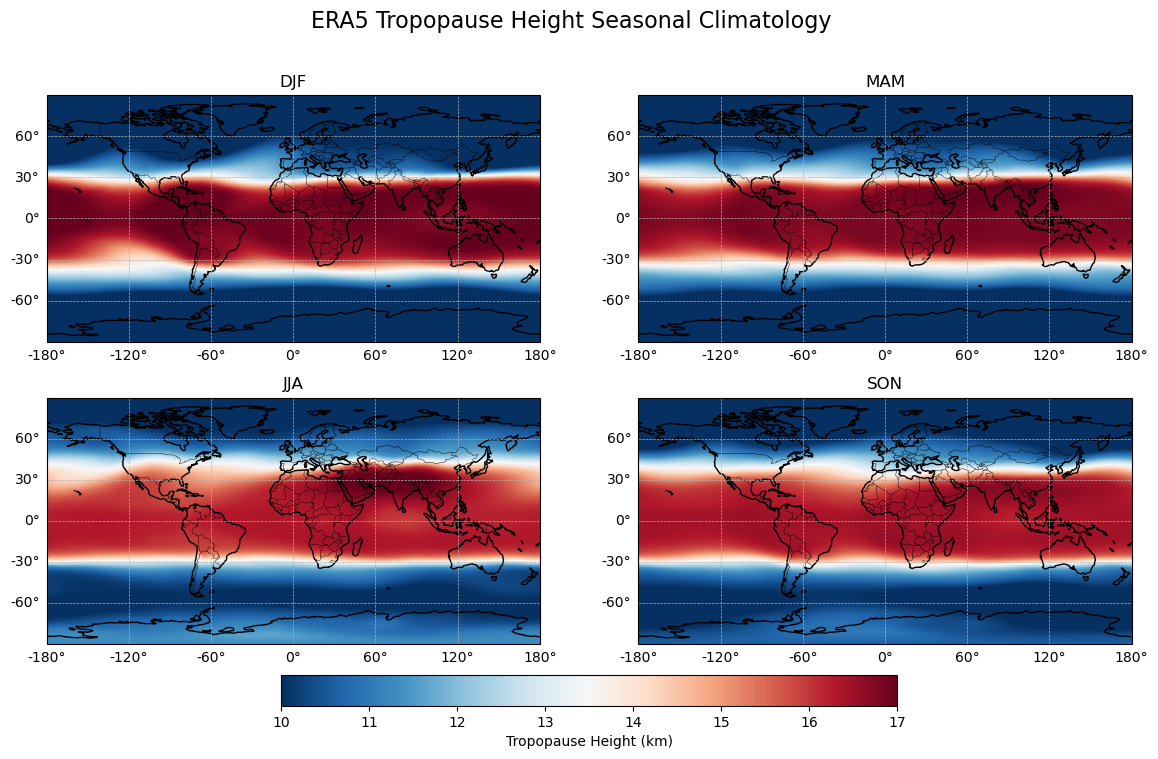

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

vmin, vmax = 10, 17
fig, axes = plt.subplots(2,2, figsize=(14,8), subplot_kw={"projection":ccrs.PlateCarree()})
axes = axes.flatten()

for ax, season in zip(axes, seasonal):
    data = seasonal[season]

    im = ax.imshow(
        data,
        extent=[data.lon.min(), data.lon.max(), data.lat.min(), data.lat.max()],
        origin="lower",
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180,181,60))
    gl.ylocator = mticker.FixedLocator(np.arange(-90,91,30))
    gl.xformatter = mticker.FuncFormatter(lambda x, _: f"{int(x)}°")
    gl.yformatter = mticker.FuncFormatter(lambda y, _: f"{int(y)}°")

    ax.set_title(season)

fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05, label="Tropopause Height (km)")
plt.suptitle("ERA5 Tropopause Height Seasonal Climatology", fontsize=16)
plt.show()

# Stop here!

KeyError: 'z_mean'

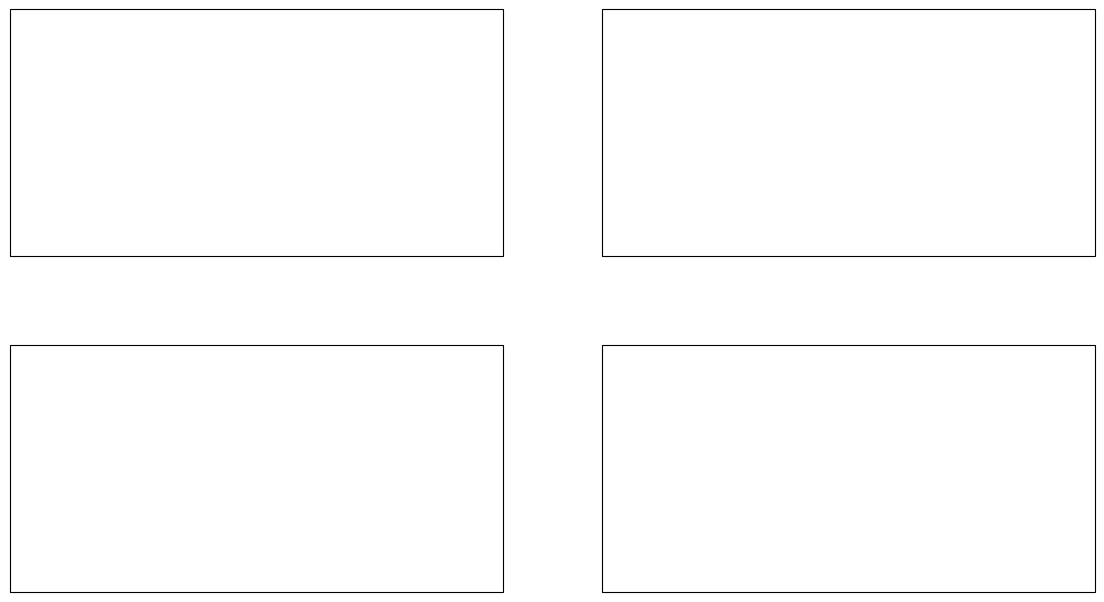

In [3]:
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Fixed color scale
vmin = 10
vmax = 18

fig, axes = plt.subplots(
    2, 2,
    figsize=(14,8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, season in zip(axes, seasonal):

    ax.set_global()

    data = seasonal[season]["z_mean"]

    # Fast imshow plotting
    mesh = ax.imshow(
        data,
        extent=[data.lon.min(), data.lon.max(),
                data.lat.min(), data.lat.max()],
        transform=ccrs.PlateCarree(),
        origin="lower",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    # Coastlines & borders
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    # Latitude / longitude gridlines with labels
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--"
    )

    # Only show left/right & bottom/top labels appropriately
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

    # Format labels
    gl.xformatter = mticker.FuncFormatter(lambda x, _: f"{int(x)}°")
    gl.yformatter = mticker.FuncFormatter(lambda y, _: f"{int(y)}°")

    ax.set_title(season)

# Shared colorbar
cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)
cbar.set_label("Tropopause Height (km)")

plt.suptitle("ERA5 Tropopause Height Seasonal Climatology", fontsize=16)
plt.show()

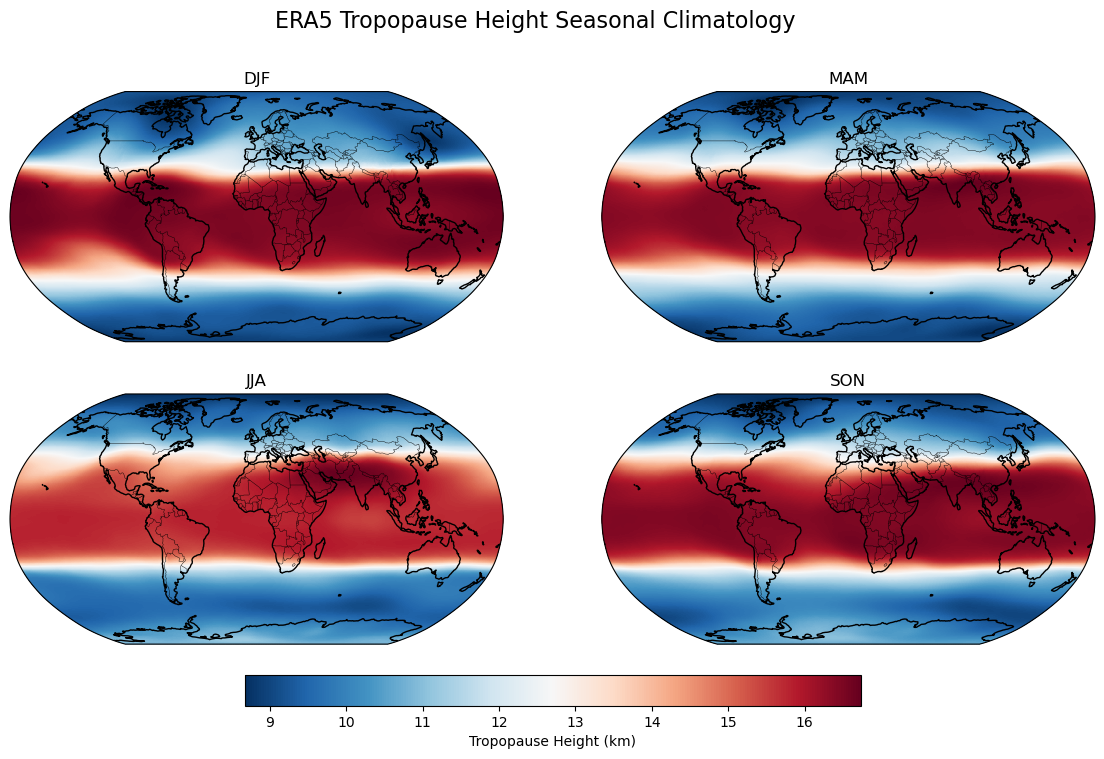

In [13]:

# -----------------------------------
# Plot seasonal maps
# -----------------------------------
fig, axes = plt.subplots(
    2,2,
    figsize=(14,8),
    subplot_kw={"projection":ccrs.Robinson()}
)

axes = axes.flatten()

for ax, season in zip(axes, seasonal):

    ax.set_global()

    data = seasonal[season]["z_mean"]

    mesh = ax.pcolormesh(
        data.lon,
        data.lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r"
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.set_title(season)

# shared colorbar
cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)

cbar.set_label("Tropopause Height (km)")

plt.suptitle("ERA5 Tropopause Height Seasonal Climatology", fontsize=16)

plt.show()

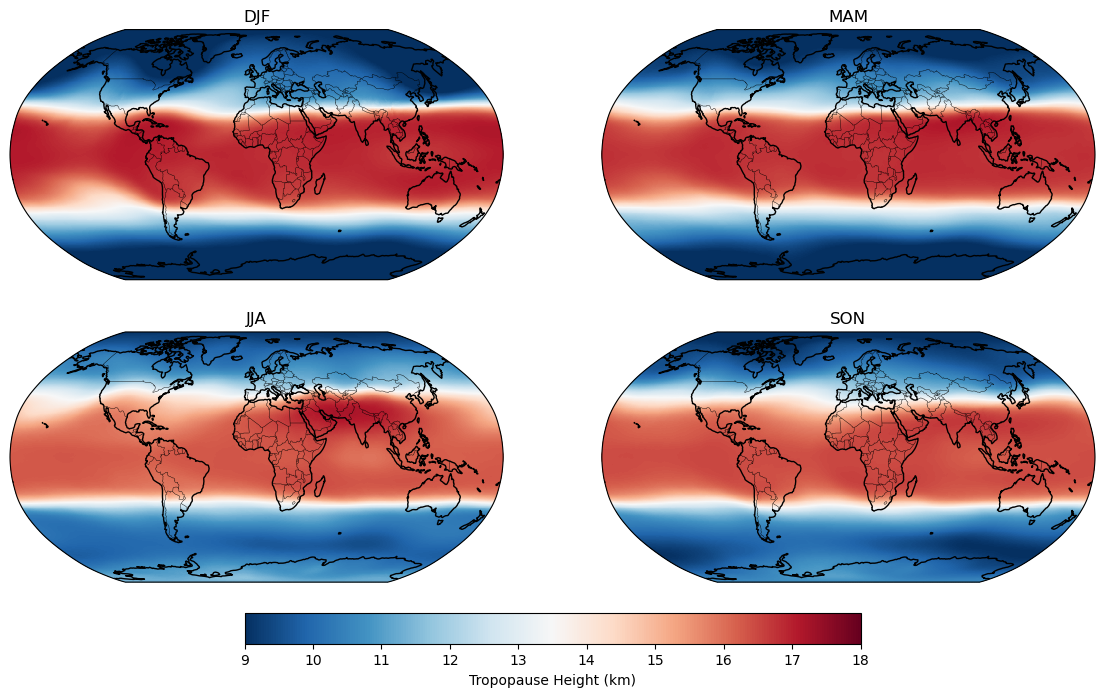

In [14]:
vmin = 9
vmax = 18

fig, axes = plt.subplots(
    2,2,
    figsize=(14,8),
    subplot_kw={"projection":ccrs.Robinson()}
)

axes = axes.flatten()

for ax, season in zip(axes, seasonal):

    ax.set_global()

    data = seasonal[season]["z_mean"]

    mesh = ax.pcolormesh(
        data.lon,
        data.lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.set_title(season)

# shared colorbar
cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)

cbar.set_label("Tropopause Height (km)")

In [ ]:
vmin = 9
vmax = 18

fig, axes = plt.subplots(
    2,2,
    figsize=(14,8),
#     subplot_kw={"projection":ccrs.Robinson()}
    subplot_kw={"projection":ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, season in zip(axes, seasonal):

    ax.set_global()

    data = seasonal[season]["z_mean"]

#     mesh = ax.pcolormesh(
#         data.lon,
#         data.lat,
#         data,
#         transform=ccrs.PlateCarree(),
#         cmap="RdBu_r",
#         vmin=vmin,
#         vmax=vmax
#     )
    
    mesh = ax.imshow(
    data,
    extent=[data.lon.min(), data.lon.max(),
            data.lat.min(), data.lat.max()],
    transform=ccrs.PlateCarree(),
    origin="lower",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.set_title(season)

# shared colorbar
cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)

cbar.set_label("Tropopause Height (km)")

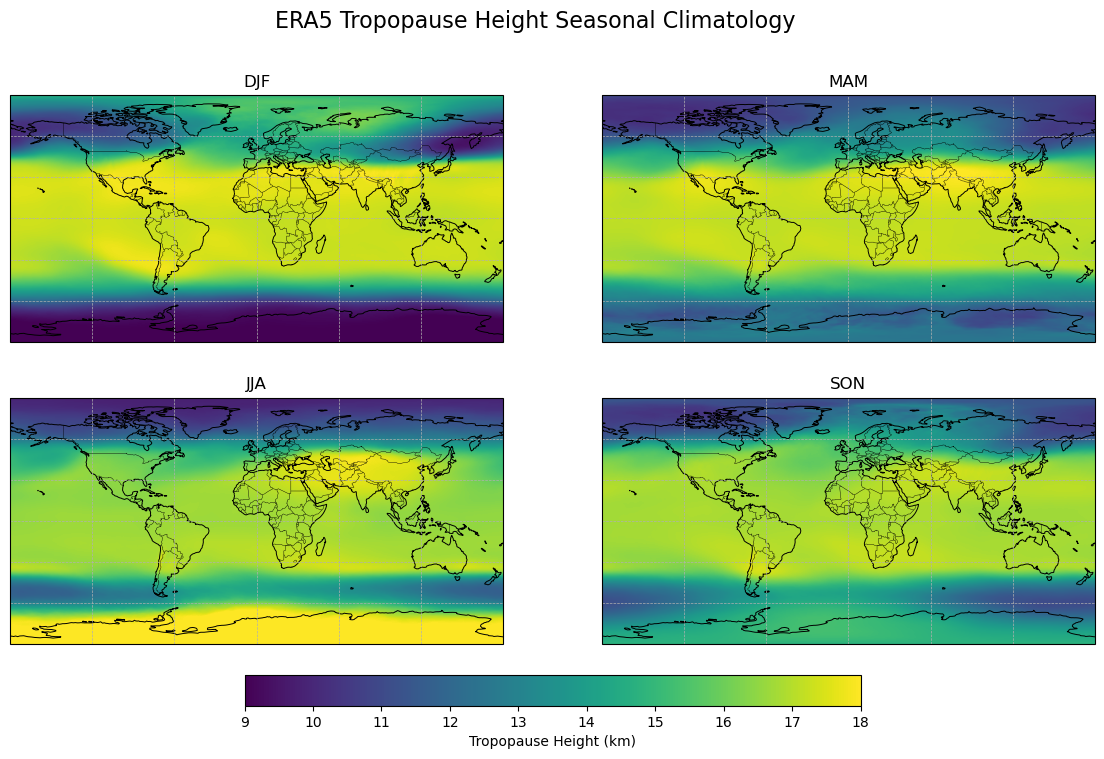

In [6]:
import matplotlib.ticker as mticker

vmin = 9
vmax = 18

fig, axes = plt.subplots(
    2,2,
    figsize=(14,8),
    subplot_kw={"projection":ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, season in zip(axes, seasonal):

    ax.set_global()

    data = seasonal[season]["z_mean"]

    mesh = ax.imshow(
        data,
        extent=[data.lon.min(), data.lon.max(),
                data.lat.min(), data.lat.max()],
        transform=ccrs.PlateCarree(),
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    # -------------------------
    # Latitude / longitude lines
    # -------------------------
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        linestyle="--"
    )

    gl.xlocator = mticker.FixedLocator(np.arange(-180,181,60))
    gl.ylocator = mticker.FixedLocator(np.arange(-90,91,30))

    ax.set_title(season)

# shared colorbar
cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)

cbar.set_label("Tropopause Height (km)")

plt.suptitle("ERA5 Tropopause Height Seasonal Climatology", fontsize=16)

plt.show()